# Plotting: Number of Training Samples per Class

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

In [14]:
experiment = "num_train_samples"

dataset = "aitv2"

logic_files = [
    "ait_logic", 
    "ait_flags",
]

baseline_models = [
    "multiclass",
    "ensemble",
]

In [15]:
experiments = {}

In [16]:
for logic_file in logic_files:
    metrics_dir = Path(f"../../experiments/{dataset}/{experiment}/deepproblog/{logic_file}/metrics")
    file_paths = list(metrics_dir.iterdir())

    mf1_scores = {}
    false_positives = {}
    detection_rates = {}
    for file_path in file_paths:
        experiment_name = str(file_path.stem)
        experiment_name_parts = experiment_name.split("_")

        if "pretrained" in experiment_name:
            model_name = f"dpl_{logic_file}_pretrained"
        else:
            continue
            model_name = f"dpl_{logic_file}_end_to_end"

        # print(f"Processing {experiment_name}...")
        data = np.load(file_path, allow_pickle=True)
        metrics = data["metrics"].item()

        subset = experiment_name_parts[-3]
        subset_size = int(subset.split("b")[0])

        mf1_scores[subset_size] = metrics["macro_f1"]
        false_positives[subset_size] = metrics["false_alarm_rate"]
        detection_rates[subset_size] = metrics["detection_rate"]

    scores_zip = zip(mf1_scores.keys(), mf1_scores.values(), false_positives.values(), detection_rates.values())
    scores_sorted = sorted(scores_zip, key=lambda x: x[0])

    experiments[model_name] = {
        "subset_sizes": [item[0] for item in scores_sorted],
        "mf1_scores": [item[1] for item in scores_sorted], 
        "false_positive_rates": [item[2] for item in scores_sorted],
        "detection_rates": [item[3] for item in scores_sorted]
    }


In [17]:
for logic_file in logic_files:
    metrics_dir = Path(f"../../experiments/{dataset}/{experiment}/deepproblog/{logic_file}/metrics")
    file_paths = list(metrics_dir.iterdir())

    mf1_scores = {}
    false_positives = {}
    detection_rates = {}
    for file_path in file_paths:
        experiment_name = str(file_path.stem)
        experiment_name_parts = experiment_name.split("_")

        if "pretrained" in experiment_name:
            continue
            model_name = f"dpl_{logic_file}_pretrained"
        else:
            model_name = f"dpl_{logic_file}_end_to_end"

        # print(f"Processing {experiment_name}...")
        data = np.load(file_path, allow_pickle=True)
        metrics = data["metrics"].item()

        subset = experiment_name_parts[-3]
        subset_size = int(subset.split("b")[0])

        mf1_scores[subset_size] = metrics["macro_f1"]
        false_positives[subset_size] = metrics["false_alarm_rate"]
        detection_rates[subset_size] = metrics["detection_rate"]

    scores_zip = zip(mf1_scores.keys(), mf1_scores.values(), false_positives.values(), detection_rates.values())
    scores_sorted = sorted(scores_zip, key=lambda x: x[0])

    experiments[model_name] = {
        "subset_sizes": [item[0] for item in scores_sorted],
        "mf1_scores": [item[1] for item in scores_sorted], 
        "false_positive_rates": [item[2] for item in scores_sorted],
        "detection_rates": [item[3] for item in scores_sorted]
    }


In [18]:
for model in baseline_models:
    model_name = f"baseline_{model}"
    metrics_dir = Path(f"../../experiments/{dataset}/{experiment}/baselines/{model}/metrics")
    file_paths = list(metrics_dir.iterdir())

    mf1_scores = {}
    false_positives = {}
    detection_rates = {}

    for file_path in file_paths:
        experiment_name = str(file_path.stem)
        experiment_name_parts = experiment_name.split("_")
        
        # print(f"Processing {experiment_name}...")
        with open(file_path) as f:
            metrics = json.load(f)
        
        subset = experiment_name_parts[-1]
        subset_size = int(subset.split("b")[0])
        mf1_scores[subset_size] = metrics["Macro F1"]
        false_positives[subset_size] = metrics["False Alarm Rate"]
        detection_rates[subset_size] = metrics["Detection Rate"]

    scores_zip = zip(mf1_scores.keys(), mf1_scores.values(), false_positives.values(), detection_rates.values())
    scores_sorted = sorted(scores_zip, key=lambda x: x[0])

    experiments[model_name] = {
        "subset_sizes": [item[0] for item in scores_sorted],
        "mf1_scores": [item[1] for item in scores_sorted], 
        "false_positive_rates": [item[2] for item in scores_sorted],
        "detection_rates": [item[3] for item in scores_sorted]
    }


In [19]:
experiments

{'dpl_ait_logic_pretrained': {'subset_sizes': [5,
   10,
   20,
   30,
   50,
   100,
   500,
   1000,
   5000,
   10000],
  'mf1_scores': [0.8614015186456296,
   0.8603554213559088,
   0.8633598811890192,
   0.8726880892440196,
   0.883179372496836,
   0.8723502573611424,
   0.8475775911510219,
   0.854127939485382,
   0.8760534360031466,
   0.871516476482981],
  'false_positive_rates': [0.0002545253102962974,
   0.0002320671946819182,
   0.00020212304052941263,
   0.0002919555029869294,
   0.0004117321195969517,
   0.00043419023521133087,
   0.001003129164108937,
   0.0007860340465032714,
   0.00035184381129194054,
   0.0003443577727538141],
  'detection_rates': [0.9909502262443439,
   0.9908171413361725,
   0.9913494809688581,
   0.9917487356933724,
   0.9924141602342295,
   0.9926803300505722,
   0.993878094224115,
   0.9946766036731435,
   0.9930795847750865,
   0.9932126696832579]},
 'dpl_ait_flags_pretrained': {'subset_sizes': [5,
   10,
   20,
   30,
   50,
   100,
   500,
   1

In [20]:
def num_samples_plot(experiments, metric, plots_dir, plots_title, save_fig=True):
    
    fig, ax = plt.subplots(figsize=(10, 6))
    all_subset_sizes = sorted({x for data in experiments.values() for x in data["subset_sizes"]})
    
    # Color palette
    colors = plt.cm.tab10.colors

    for i, (logic_file, data) in enumerate(experiments.items()):
        ax.plot(
            data["subset_sizes"], 
            data[metric], 
            marker='o',
            markersize=8,
            linewidth=2.5,
            color=colors[i % len(colors)],
            label=logic_file
        )
    
    ax.set_xscale('log')
    ax.set_xticks(all_subset_sizes)
    ax.set_xticklabels([f'{x:,}' for x in all_subset_sizes])
    
    ax.set_xlabel('Number of Training Samples', fontsize=12, fontweight='medium')
    ax.set_ylabel(metric.replace("_", " ").title(), fontsize=12, fontweight='medium')
    ax.set_title(plots_title, fontsize=14, fontweight='bold', pad=15)
    
    ax.legend(frameon=True, fancybox=True, shadow=False, fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    
    plt.tight_layout()
    
    plots_dir.mkdir(parents=True, exist_ok=True)
    if save_fig:
        plt.savefig(plots_dir / f"{metric}.png", dpi=150, bbox_inches='tight')
    plt.show()


In [21]:
plots_dir = Path(f"../../reports/{dataset}/{experiment}")

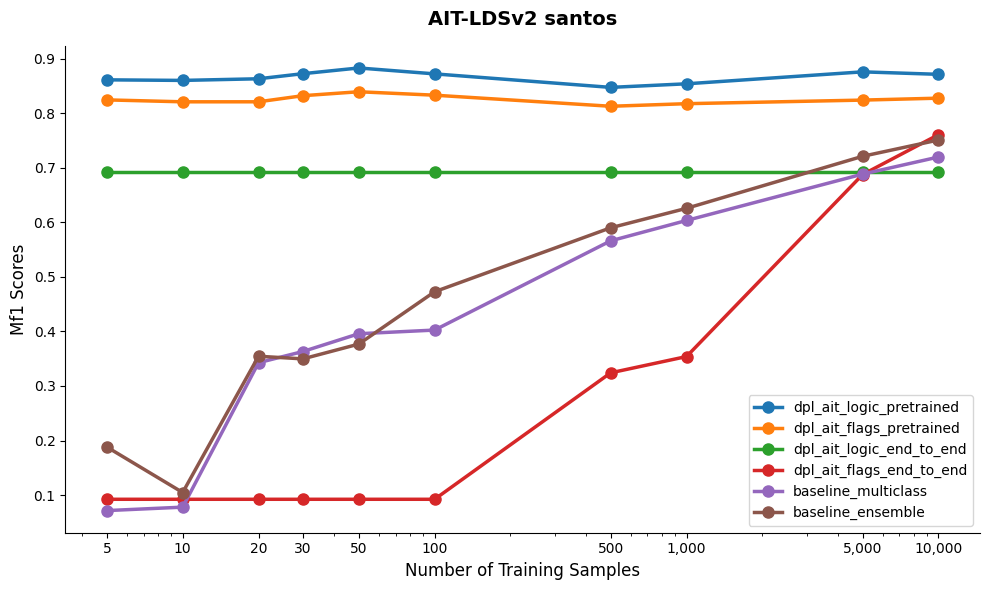

In [22]:
plots_title = f"AIT-LDSv2 santos"
metric = "mf1_scores"
num_samples_plot(experiments, metric, plots_dir, plots_title)

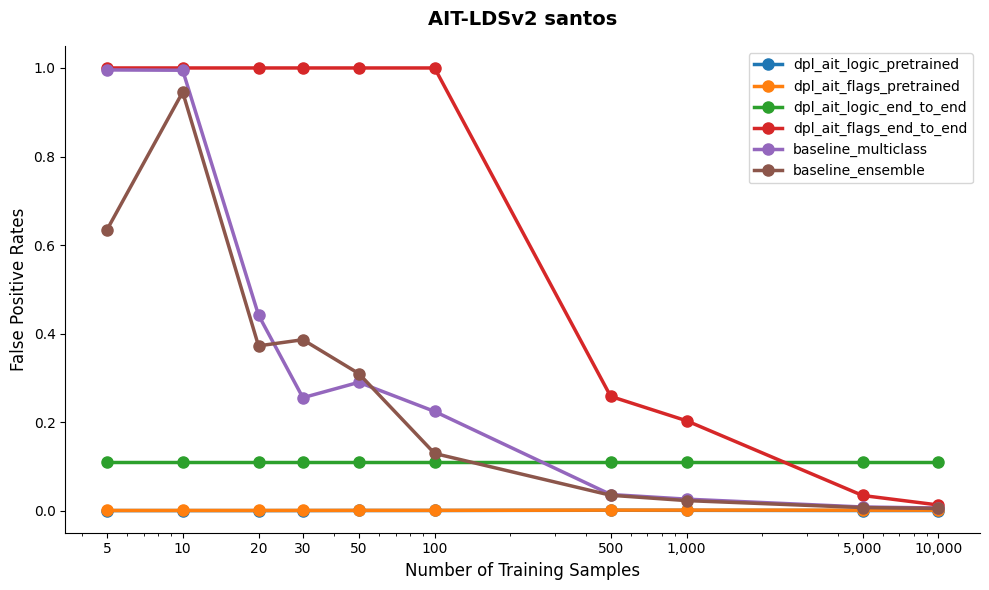

In [23]:
metric = "false_positive_rates"
num_samples_plot(experiments, metric, plots_dir, plots_title)

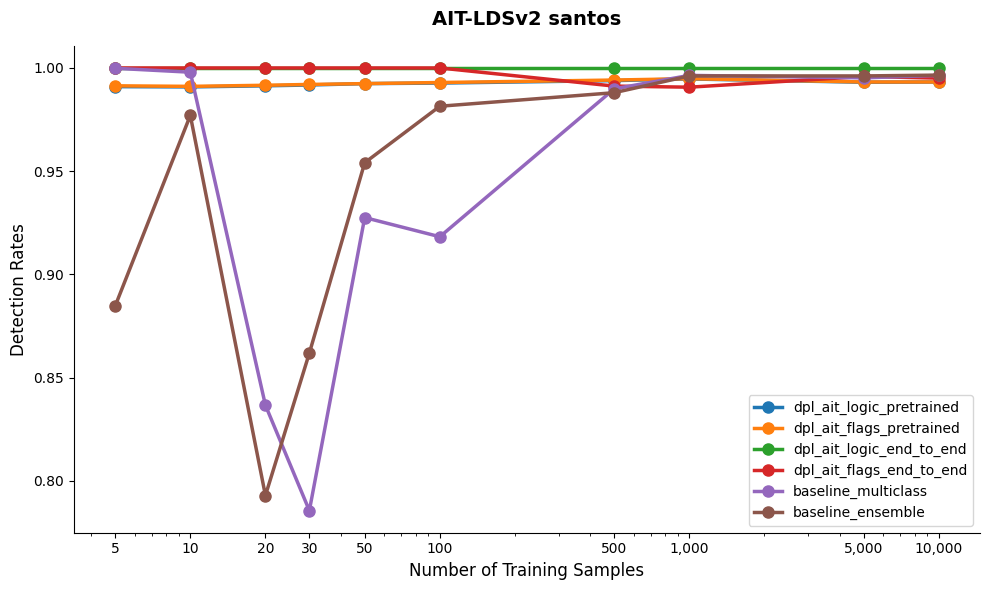

In [24]:
metric = "detection_rates"
num_samples_plot(experiments, metric, plots_dir, plots_title)